Dependencies

In [21]:
import pandas as pd
import string
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Data Collection

In [22]:
df = pd.read_csv('final_merged_dataset.csv', low_memory=False)

In [23]:
df.head()

,text,label
0,at work and got loads to do b4 I leave today....,negative
1,Will have to wait to next week to meet C and ...,negative
2,@SexyRubie save it for the (INDOOR) bbq. Its g...,negative
3,"you won't be disappointed, @yanghuawawa has th...",positive
4,@TkTooKool God bless you 2,positive


In [24]:
df.tail()

,text,label
1604911,Protected edit request on 24 October 2015 \n\n...,toxic
1604912,hopefully i'll get a mention on radio 1,positive
1604913,Wardrobe sorted! So many clothes! Now gotta tr...,negative
1604914,Watching House Hunters. They are hunting in th...,positive
1604915,No luck for Nori's wife,negative


In [25]:
df.describe()

,text,label
count,1604916,1604916
unique,1602691,4
top,@kaliie you sure? I can if you want to BECAUS...,negative
freq,2,797101


Data Cleaning & Preprocessing

In [26]:
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['text', 'label'])

In [27]:
def manual_preprocess(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = " ".join(text.split())
    return text

Data Balancing

In [28]:
counts = df['label'].value_counts()
min_size = counts.min()
df_balanced = df.groupby('label').sample(n=min_size, random_state=42)

Feature Design

In [29]:
TfidfVectorizer(ngram_range=(1,2), max_features=40000)

TfidfVectorizer(max_features=40000, ngram_range=(1, 2))

Model Selection (Multinomial Naive Bayes)

In [30]:
MultinomialNB(alpha=0.1)

MultinomialNB(alpha=0.1)

Pipeline Integration

In [31]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=40000)),
    ('mnb', MultinomialNB(alpha=0.1))
])

Model Training

In [32]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'],
    df_balanced['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

# Train only on training data
model.fit(X_train, y_train)



Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=40000, ngram_range=(1, 2))),
                ('mnb', MultinomialNB(alpha=0.1))])

Model Evaluation

In [33]:
# Predict on test data
preds = model.predict(X_test)

# Evaluate
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

    negative       0.67      0.62      0.64       250
     neutral       0.98      1.00      0.99       250
    positive       0.70      0.62      0.65       250
       toxic       0.82      0.96      0.88       250

    accuracy                           0.80      1000
   macro avg       0.79      0.80      0.79      1000
weighted avg       0.79      0.80      0.79      1000



In [40]:
print(model.classes_)

['negative' 'neutral' 'positive' 'toxic']


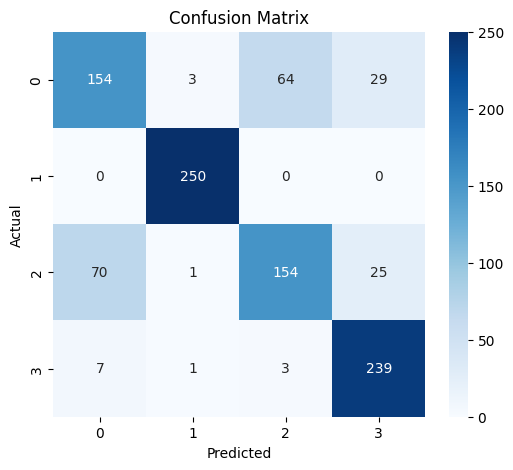

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Deployment 

In [34]:
import joblib
joblib.dump(model, "toxicity_model.pkl")

['toxicity_model.pkl']

Testing

In [36]:
import joblib

model = joblib.load("toxicity_model.pkl")

text = input("Enter text: ")

prediction = model.predict([text])[0]

# Prediction probabilities
probs = model.predict_proba([text])[0]

# Output
print(text)
print("\nPrediction:", prediction.upper())
print("Class Probabilities:")

for class_name, prob in zip(model.classes_, probs):
    print(f"{class_name}: {prob:.4f}")

    import numpy as np

confidence = np.max(probs) * 100
print("Confidence:", f"{confidence:.2f}%")

it keeps getting worse.

Prediction: NEGATIVE
Class Probabilities:
negative: 0.7343
neutral: 0.0109
positive: 0.0828
toxic: 0.1720
Confidence: 73.43%
